# NEO-versus-OTHER pilot — selected-centre map/score diagnostic

A **contained diagnostic on three sky centres**, not a performance evaluation. It asks one
question: if the non-NEO denominator is estimated as a single directly pooled, physically weighted
`OTHER` density instead of three separate populations, how do the scores and the coverage change on
exactly the TEST2 rows that were already scored with the frozen maps?

What this notebook does **not** do: rebuild the frozen maps, rescore TEST2 globally, draw a new
evaluation population, touch digest2, change the frozen v1 scorer, or run a ROC study.

### The estimator, stated before any result

The frozen builder estimates each non-NEO population separately and applies one scalar physical
normalisation, `rho_pop = n0_pop / eff_pop` with `eff_pop = f_split(pop, magnitude_bin)`.

Pooling is not concatenation, because **`f_split` differs by population and by bin** — measured
across the 42 populated bins, all 42 differ (MBA ~0.60, TNO 0.52-0.74, Trojans 0.49-0.64). Each
pooled sample therefore carries its own physical weight `w_i = 1/f_split(pop_i, bin)`.

The pilot keeps the sealed closed-form kNN estimator untouched and applies the local mean physical
weight of the same k neighbours it already queries:

    n0(x)        = ( k(k+1)/2 - 1/2 ) / ( pi * sum_j d_j^2 )     <- sealed, verbatim
    rho_OTHER(x) = n0(x) * mean_{j in kNN(x)} w_j

When every pooled sample shares one weight this is exactly `n0/eff`, identical to the frozen
single-population line. The pilot estimator is a **strict generalisation** of the frozen one.

`rho_NEO` is copied verbatim from the frozen maps, so the numerator is unchanged and the entire
difference lives in the denominator.

### Selection caveat, stated up front

The three centres were selected by a fixed rule — most old-valid four-population rows, ties broken
by ascending centre id. That rule necessarily picks the **best-covered** centres. These three are
~94% old-valid against 43.96% globally, so this pilot mainly tests **agreement**, and can show only
a little of the coverage repair that motivates `OTHER`. A coverage-repair demonstration needs
poorly covered centres and is not what this selection produces.

In [1]:
import hashlib, json, subprocess, sys, time
from pathlib import Path
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib; import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":10.5,"axes.grid":True,"grid.alpha":0.3,
                     "axes.titlesize":11.5,"axes.labelsize":10.5,"legend.fontsize":8.5})

W   = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
OUT = W/"outputs"/"neomod3_pneo_other_pilot"
FIG = OUT/"figures"; FIG.mkdir(parents=True, exist_ok=True)
C_OLD, C_NEW = "tab:blue", "tab:red"
print("output dir:", OUT)

output dir: /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_pneo_other_pilot


## 1 — Provenance

In [2]:
def sha256(p, buf=8*1024*1024):
    h=hashlib.sha256()
    with open(p,"rb") as f:
        while (b:=f.read(buf)): h.update(b)
    return h.hexdigest()

RC = json.load(open(W/"outputs/neomod3_new_vs_legacy_score_regime/RUN_RECEIPT.json"))
ARCH = json.load(open(W/"outputs/neomod3_current_maps_archive/current_maps_manifest.json"))
prov = {}
for nm in ("TEST2_SCORED","TEST2_TRACKLETS"):
    p = Path(RC["inputs"][nm]["path"]); got = sha256(p)
    prov[nm] = {"path": str(p), "sha256": got}
    assert got == RC["inputs"][nm]["sha256"], f"{nm} changed since the proof notebook"
    print(f"{nm:16s} {got[:16]}...  matches proof-notebook receipt")

print(f"\nfrozen map root   {ARCH['map_root']}")
print(f"map reference epoch {ARCH['map_reference_epoch']}   (NOT the archive date)")
print(f"map seal          {ARCH['seals']['map_build_seal_v2_sha256'][:16]}...")
print(f"scorer seal       {ARCH['seals']['scorer_seal_v1_sha256'][:16]}...")
print(f"maps verified     {ARCH['sealed_hash_verification']['matched']}/"
      f"{ARCH['sealed_hash_verification']['n_sealed']} match the seal")
git = subprocess.run(["git","-C",str(W/"neomod"),"rev-parse","HEAD"],
                     capture_output=True,text=True).stdout.strip()
print(f"repo HEAD         {git}")
for nm,rel in (("pilot_builder","pipeline/build_neomod3_pneo_other_pilot.py"),
               ("pilot_scorer","pipeline/score_neomod3_pneo_other_pilot.py")):
    prov[nm]={"path":rel,"sha256":sha256(W/"neomod"/rel)}
    print(f"{nm:16s} {prov[nm]['sha256'][:16]}...")

TEST2_SCORED     8b6e1de609bf4831...  matches proof-notebook receipt


TEST2_TRACKLETS  e374547893e2945a...  matches proof-notebook receipt

frozen map root   /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_mag025_k150_maps_v2
map reference epoch 2027-08-25T00:00:00   (NOT the archive date)
map seal          a010bb1bf2e421a3...
scorer seal       0e61ec37e263e9a4...
maps verified     667/667 match the seal
repo HEAD         31d16327f136386e730c6def95fef0b0bea3c6f8
pilot_builder    c0c1127aacacf726...
pilot_scorer     6fb4706f5900e168...


In [3]:
sel = pd.read_csv(OUT/"selected_centers.csv")
print("SELECTED CENTRES  (rule: top 3 by old-valid count, ties by ascending id)")
print(sel[["rank","map_center_id","n_old_valid","n_rows_total","frac_valid"]]
        .to_string(index=False, float_format=lambda z: f"{z:.4f}"))
allc = pd.read_csv(OUT/"center_valid_counts_all.csv")
print(f"\nranked among {len(allc)} centres; 4th place had {allc.n_old_valid.iloc[3]:,} "
      f"vs 3rd {allc.n_old_valid.iloc[2]:,} -> no tie at the boundary")
CENS = sel.map_center_id.tolist()

pm = []
for c in CENS:
    m = json.loads(np.load(OUT/"pilot_maps"/f"pilot_{c}.npz", allow_pickle=True)["meta_json"].item())
    pm.append(m)
meta = pm[0]
print("\nPILOT MAP SETTINGS (must match the frozen configuration except for the aggregation)")
for k in ("epoch","grid_lim","grid_step","max_sep_deg","k_OTHER","k_NEO_from_frozen_maps",
          "gaussian_smoothing","support_masking","density_engine","rho_NEO_origin"):
    print(f"  {k:24s} {meta[k]}")
assert meta["epoch"] == ARCH["map_reference_epoch"], "pilot epoch differs from the frozen epoch"
assert meta["grid_lim"] == ARCH["velocity_grid"]["limits_deg_per_day"]
assert meta["grid_step"] == ARCH["velocity_grid"]["step_deg_per_day"]
assert meta["gaussian_smoothing"] is False and meta["support_masking"] is False
print("\nasserted identical: epoch, velocity grid, smoothing, masking")

SELECTED CENTRES  (rule: top 3 by old-valid count, ties by ascending id)
 rank   map_center_id  n_old_valid  n_rows_total  frac_valid
    1 dlon-130_lat+08         2212          2336      0.9469
    2 dlon-120_lat+08         2174          2288      0.9502
    3 dlon+130_lat+08         2098          2242      0.9358

ranked among 341 centres; 4th place had 2,088 vs 3rd 2,098 -> no tie at the boundary



PILOT MAP SETTINGS (must match the frozen configuration except for the aggregation)
  epoch                    2027-08-25T00:00:00
  grid_lim                 [-5.0, 5.0]
  grid_step                0.01
  max_sep_deg              30.0
  k_OTHER                  10
  k_NEO_from_frozen_maps   150
  gaussian_smoothing       False
  support_masking          False
  density_engine           closed_form + local mean physical weight
  rho_NEO_origin           copied verbatim from the frozen map set

asserted identical: epoch, velocity grid, smoothing, masking


## 2 — Join the old and new scores on identical rows

In [4]:
old = pd.read_parquet(OUT/"pilot_rows.parquet")
new = pd.read_parquet(OUT/"pilot_scored.parquet")
assert len(old)==len(new) and (old.tracklet_uid.to_numpy()==new.tracklet_uid.to_numpy()).all()
d = new.copy()
d["score_diff_old_minus_new"] = d.P_NEO_new - d.p_NEO_vs_OTHER
print(f"rows {len(d):,}   centres {d.center_label.nunique()}   "
      f"unique tracklet ids {d.tracklet_uid.nunique():,}")
print(f"\nold four-population valid : {int(d.new_vdp_valid.sum()):,} "
      f"({100*d.new_vdp_valid.mean():.2f}%)")
print(f"new NEO-vs-OTHER valid    : {int(d.pilot_valid.sum()):,} "
      f"({100*d.pilot_valid.mean():.2f}%)")
both = d.new_vdp_valid & d.pilot_valid
print(f"both valid (paired)       : {int(both.sum()):,}")

rows 6,866   centres 3   unique tracklet ids 6,866

old four-population valid : 6,484 (94.44%)
new NEO-vs-OTHER valid    : 6,852 (99.80%)
both valid (paired)       : 6,484


## 3 — Coverage

In [5]:
rows=[]
for c in CENS:
    g = d[d.center_label==c]
    rows.append(dict(map_center_id=c, n_rows=len(g),
                     n_old_valid=int(g.new_vdp_valid.sum()),
                     n_new_valid=int(g.pilot_valid.sum()),
                     frac_old=g.new_vdp_valid.mean(), frac_new=g.pilot_valid.mean(),
                     delta_frac=g.pilot_valid.mean()-g.new_vdp_valid.mean(),
                     n_old_only=int((g.new_vdp_valid & ~g.pilot_valid).sum()),
                     n_new_only=int((~g.new_vdp_valid & g.pilot_valid).sum())))
cov = pd.DataFrame(rows)
print("COVERAGE BY CENTRE")
print(cov.to_string(index=False, float_format=lambda z: f"{z:.4f}"))
cov.to_csv(OUT/"coverage_by_center.csv", index=False)

rows=[]
for p in ["NEO","MBA","TNO","Trojans"]:
    g = d[d.population==p]
    if not len(g): continue
    rows.append(dict(population=p, n_rows=len(g),
                     n_old_valid=int(g.new_vdp_valid.sum()), frac_old=g.new_vdp_valid.mean(),
                     n_new_valid=int(g.pilot_valid.sum()),   frac_new=g.pilot_valid.mean(),
                     delta_frac=g.pilot_valid.mean()-g.new_vdp_valid.mean(),
                     n_old_only=int((g.new_vdp_valid & ~g.pilot_valid).sum()),
                     n_new_only=int((~g.new_vdp_valid & g.pilot_valid).sum())))
covp = pd.DataFrame(rows)
print("\nCOVERAGE BY TRUE POPULATION")
print(covp.to_string(index=False, float_format=lambda z: f"{z:.4f}"))
covp.to_csv(OUT/"coverage_by_population.csv", index=False)

COVERAGE BY CENTRE
  map_center_id  n_rows  n_old_valid  n_new_valid  frac_old  frac_new  delta_frac  n_old_only  n_new_only
dlon-130_lat+08    2336         2212         2331    0.9469    0.9979      0.0509           0         119
dlon-120_lat+08    2288         2174         2283    0.9502    0.9978      0.0476           0         109
dlon+130_lat+08    2242         2098         2238    0.9358    0.9982      0.0624           0         140

COVERAGE BY TRUE POPULATION
population  n_rows  n_old_valid  frac_old  n_new_valid  frac_new  delta_frac  n_old_only  n_new_only
       NEO     247          228    0.9231          246    0.9960      0.0729           0          18
       MBA    5663         5327    0.9407         5651    0.9979      0.0572           0         324
       TNO      45           45    1.0000           45    1.0000      0.0000           0           0
   Trojans     911          884    0.9704          910    0.9989      0.0285           0          26


In [6]:
print("OLD-VALID BUT NEW-INVALID")
oo = d[d.new_vdp_valid & ~d.pilot_valid]
print(f"  {len(oo):,} rows")
if len(oo): print(oo.pilot_reason.value_counts().to_string())
print("\nNEW-VALID BUT OLD-INVALID")
nn = d[~d.new_vdp_valid & d.pilot_valid]
print(f"  {len(nn):,} rows")
if len(nn):
    print(nn.new_vdp_reason.value_counts().to_string())
    print("\n  by true population:"); print("  "+nn.population.value_counts().to_string().replace("\n","\n  "))
print("\nREASONS, OLD vs NEW (all rows)")
cmp_reason = pd.crosstab(d.new_vdp_reason, d.pilot_reason)
print(cmp_reason.to_string())

OLD-VALID BUT NEW-INVALID
  0 rows

NEW-VALID BUT OLD-INVALID
  368 rows
new_vdp_reason
missing_population_density:TNO    368

  by true population:
  population
  MBA        324
  Trojans     26
  NEO         18

REASONS, OLD vs NEW (all rows)
pilot_reason                                    missing_population_density:NEO  missing_population_density:NEO,OTHER    ok  outside_velocity_grid
new_vdp_reason                                                                                                                                   
missing_population_density:NEO,MBA,TNO,Trojans                               0                                     1     0                      0
missing_population_density:NEO,TNO                                           1                                     0     0                      0
missing_population_density:NEO,TNO,Trojans                                  11                                     0     0                      0
missing_population_densit

## 4 — Score comparison on the paired rows

The cross-check the living plan asks for: where all four component densities exist,
`p_NEO_vs_OTHER` should agree with `p_NEO_4pop`. Any disagreement is the pooled estimator's
different bandwidth, not a different quantity.

In [7]:
b = d[both]
x, y = b.P_NEO_new.to_numpy(float), b.p_NEO_vs_OTHER.to_numpy(float)
diff = x - y
qs = [0.01,0.05,0.25,0.50,0.75,0.95,0.99]
comp = pd.DataFrame({
  "quantile": qs,
  "old_p_NEO_4pop": np.quantile(x, qs),
  "new_p_NEO_vs_OTHER": np.quantile(y, qs),
  "old_minus_new": np.quantile(diff, qs)})
print("SCORE QUANTILES ON PAIRED ROWS")
print(comp.to_string(index=False, float_format=lambda z: f"{z:.6f}"))
print(f"\nmedian |old - new|      {np.median(np.abs(diff)):.6e}")
print(f"mean    old - new       {diff.mean():+.6e}")
print(f"max    |old - new|      {np.abs(diff).max():.6e}")
print(f"Spearman rank corr      {pd.Series(x).corr(pd.Series(y), method='spearman'):.6f}")
print(f"Pearson corr            {pd.Series(x).corr(pd.Series(y)):.6f}")
rows=[]
for p in ["NEO","MBA","TNO","Trojans"]:
    g=b[b.population==p]
    if len(g)<5: continue
    dd=(g.P_NEO_new-g.p_NEO_vs_OTHER)
    rows.append(dict(population=p, n=len(g),
                     median_old=g.P_NEO_new.median(), median_new=g.p_NEO_vs_OTHER.median(),
                     median_diff=dd.median(), mean_diff=dd.mean(),
                     max_abs_diff=dd.abs().max()))
bypop=pd.DataFrame(rows)
print("\nBY TRUE POPULATION (paired rows)")
print(bypop.to_string(index=False, float_format=lambda z: f"{z:.6f}"))
comp.to_csv(OUT/"score_comparison.csv", index=False)
bypop.to_csv(OUT/"score_comparison_by_population.csv", index=False)

SCORE QUANTILES ON PAIRED ROWS
 quantile  old_p_NEO_4pop  new_p_NEO_vs_OTHER  old_minus_new
 0.010000        0.000093            0.000093      -0.035114
 0.050000        0.000173            0.000173      -0.000055
 0.250000        0.000323            0.000323      -0.000001
 0.500000        0.000480            0.000481      -0.000000
 0.750000        0.000781            0.000782      -0.000000
 0.950000        0.006590            0.006631       0.000001
 0.990000        0.718836            0.773589       0.000056

median |old - new|      1.739489e-07
mean    old - new       -1.000823e-03
max    |old - new|      1.698280e-01


Spearman rank corr      0.998707
Pearson corr            0.997800

BY TRUE POPULATION (paired rows)
population    n  median_old  median_new  median_diff  mean_diff  max_abs_diff
       NEO  228    0.390248    0.420513    -0.013525  -0.028143      0.169828
       MBA 5327    0.000482    0.000482    -0.000000  -0.000012      0.012266
       TNO   45    0.000002    0.000002    -0.000000  -0.000000      0.000000
   Trojans  884    0.000407    0.000415    -0.000008  -0.000007      0.000421


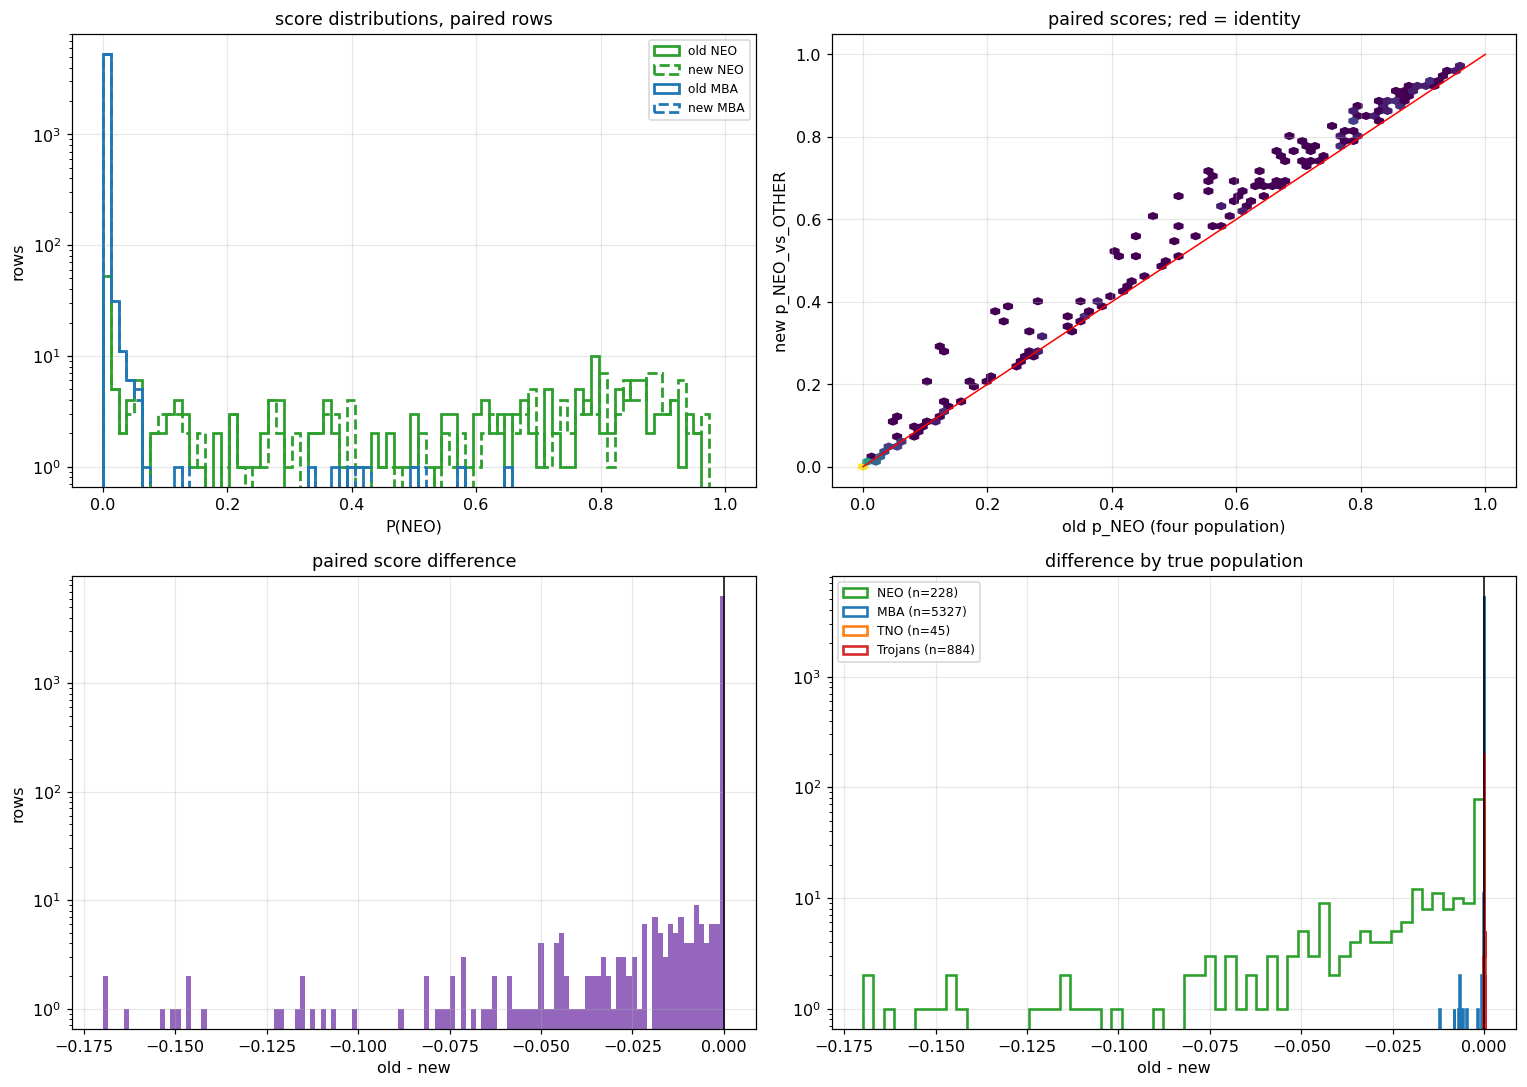

In [8]:
fig, ax = plt.subplots(2,2, figsize=(14,10))
bins=np.linspace(0,1,80)
for p,c_ in (("NEO","tab:green"),("MBA","tab:blue")):
    g=b[b.population==p]
    ax[0,0].hist(g.P_NEO_new, bins=bins, histtype="step", lw=1.8, color=c_, label=f"old {p}")
    ax[0,0].hist(g.p_NEO_vs_OTHER, bins=bins, histtype="step", lw=1.8, ls="--", color=c_,
                 label=f"new {p}")
ax[0,0].set_yscale("log"); ax[0,0].set_xlabel("P(NEO)"); ax[0,0].set_ylabel("rows")
ax[0,0].set_title("score distributions, paired rows"); ax[0,0].legend(fontsize=8)

ax[0,1].hexbin(x, y, gridsize=70, bins="log", cmap="viridis")
ax[0,1].plot([0,1],[0,1],"r-",lw=1)
ax[0,1].set_xlabel("old p_NEO (four population)"); ax[0,1].set_ylabel("new p_NEO_vs_OTHER")
ax[0,1].set_title("paired scores; red = identity")

ax[1,0].hist(diff, bins=120, color="tab:purple")
ax[1,0].axvline(0,color="k",lw=1); ax[1,0].set_yscale("log")
ax[1,0].set_xlabel("old - new"); ax[1,0].set_ylabel("rows")
ax[1,0].set_title("paired score difference")

for p,c_ in (("NEO","tab:green"),("MBA","tab:blue"),("TNO","tab:orange"),("Trojans","tab:red")):
    g=b[b.population==p]
    if len(g)<5: continue
    ax[1,1].hist(g.P_NEO_new-g.p_NEO_vs_OTHER, bins=60, histtype="step", lw=1.7,
                 color=c_, label=f"{p} (n={len(g)})")
ax[1,1].axvline(0,color="k",lw=1); ax[1,1].set_yscale("log")
ax[1,1].set_xlabel("old - new"); ax[1,1].set_title("difference by true population")
ax[1,1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"01_score_comparison.png", dpi=130, bbox_inches="tight"); plt.show()

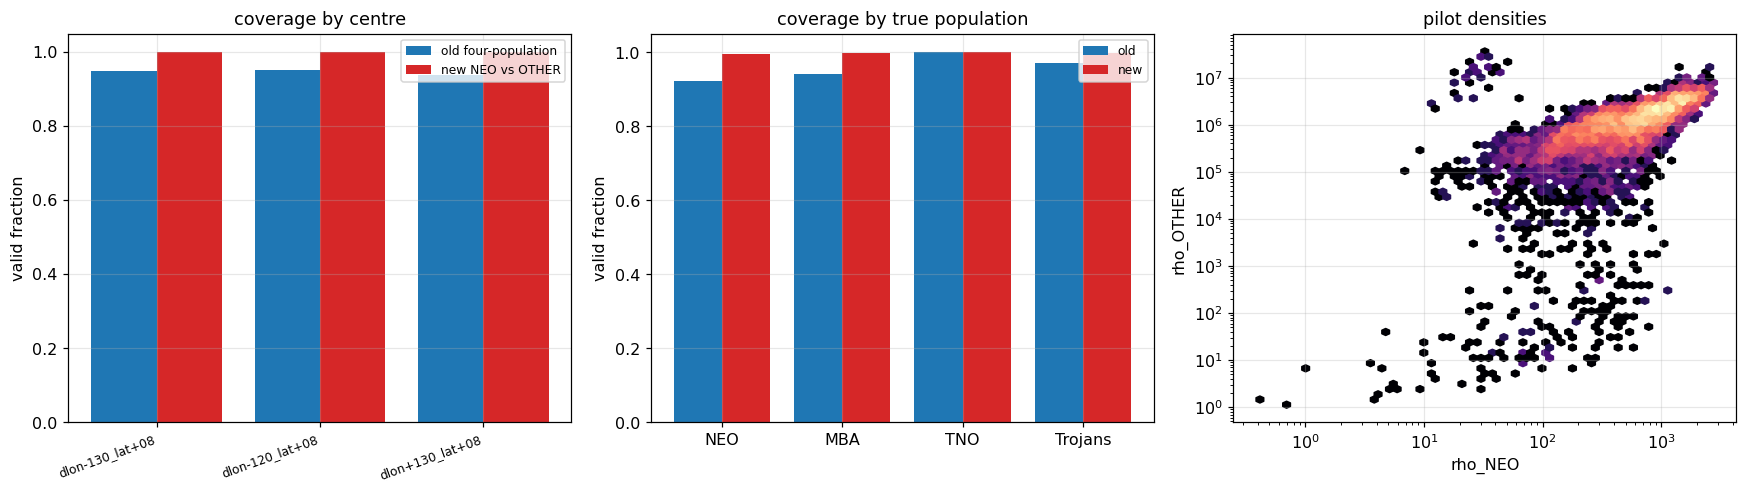

In [9]:
fig, ax = plt.subplots(1,3, figsize=(16,4.6))
xp=np.arange(len(cov))
ax[0].bar(xp-0.2, cov.frac_old, 0.4, color=C_OLD, label="old four-population")
ax[0].bar(xp+0.2, cov.frac_new, 0.4, color=C_NEW, label="new NEO vs OTHER")
ax[0].set_xticks(xp); ax[0].set_xticklabels(cov.map_center_id, rotation=20, ha="right", fontsize=8)
ax[0].set_ylabel("valid fraction"); ax[0].set_title("coverage by centre"); ax[0].legend(fontsize=8)
xp=np.arange(len(covp))
ax[1].bar(xp-0.2, covp.frac_old, 0.4, color=C_OLD, label="old")
ax[1].bar(xp+0.2, covp.frac_new, 0.4, color=C_NEW, label="new")
ax[1].set_xticks(xp); ax[1].set_xticklabels(covp.population)
ax[1].set_ylabel("valid fraction"); ax[1].set_title("coverage by true population"); ax[1].legend(fontsize=8)
ax[2].hexbin(b.rho_NEO_pilot, b.rho_OTHER_pilot, xscale="log", yscale="log",
             gridsize=60, bins="log", cmap="magma")
ax[2].set_xlabel("rho_NEO"); ax[2].set_ylabel("rho_OTHER"); ax[2].set_title("pilot densities")
plt.tight_layout(); plt.savefig(FIG/"02_coverage.png", dpi=130, bbox_inches="tight"); plt.show()

## 5 — Row-level output and receipt

In [10]:
cols = ["tracklet_uid","center_label","magnitude_bin","population","w_phys","mean_mag_V",
        "vlam","vbeta",
        "P_NEO_new","new_vdp_valid","new_vdp_reason","n_pops_new","total_density_new",
        "rho_NEO_new","rho_MBA_new","rho_TNO_new","rho_Trojans_new",
        "p_NEO_vs_OTHER","pilot_valid","pilot_reason","rho_NEO_pilot","rho_OTHER_pilot",
        "total_density_pilot","score_diff_old_minus_new"]
row = d[[c for c in cols if c in d.columns]].copy()
row["map_center_id"]    = row.center_label
row["magnitude_bin_id"] = row.magnitude_bin
row["map_seal"]         = ARCH["seals"]["map_build_seal_v2_sha256"]
row["scorer_seal_v1"]   = ARCH["seals"]["scorer_seal_v1_sha256"]
row["pilot_builder_sha256"] = prov["pilot_builder"]["sha256"]
row["pilot_scorer_sha256"]  = prov["pilot_scorer"]["sha256"]
row.to_csv(OUT/"old_vs_new_scores.csv", index=False)
print(f"wrote {OUT/'old_vs_new_scores.csv'}  rows {len(row):,}  columns {len(row.columns)}")
print(list(row.columns))

wrote /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_pneo_other_pilot/old_vs_new_scores.csv  rows 6,866  columns 30
['tracklet_uid', 'center_label', 'magnitude_bin', 'population', 'w_phys', 'mean_mag_V', 'vlam', 'vbeta', 'P_NEO_new', 'new_vdp_valid', 'new_vdp_reason', 'n_pops_new', 'total_density_new', 'rho_NEO_new', 'rho_MBA_new', 'rho_TNO_new', 'rho_Trojans_new', 'p_NEO_vs_OTHER', 'pilot_valid', 'pilot_reason', 'rho_NEO_pilot', 'rho_OTHER_pilot', 'total_density_pilot', 'score_diff_old_minus_new', 'map_center_id', 'magnitude_bin_id', 'map_seal', 'scorer_seal_v1', 'pilot_builder_sha256', 'pilot_scorer_sha256']


In [11]:
receipt = {
 "notebook": "neomod3_pneo_other_pilot.ipynb",
 "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
 "purpose": "selected-centre NEO-vs-OTHER map/score diagnostic; NOT a performance evaluation",
 "git_commit": git,
 "selected_centers": CENS,
 "selection_rule": "top 3 by count of old four-population valid TEST2 rows; "
                   "ties broken by ascending map_center_id",
 "selection_caveat": "this rule selects the BEST-covered centres, so the pilot demonstrates "
                     "agreement rather than coverage repair",
 "inputs": prov,
 "frozen_map_root": ARCH["map_root"],
 "map_reference_epoch": ARCH["map_reference_epoch"],
 "map_seal_sha256": ARCH["seals"]["map_build_seal_v2_sha256"],
 "scorer_seal_v1_sha256": ARCH["seals"]["scorer_seal_v1_sha256"],
 "pilot_map_settings": meta,
 "other_estimator": "rho_OTHER(x) = n0(x) * mean_{j in kNN(x)} w_j, with n0 the sealed closed-form "
                    "kNN density and w_j = 1/f_split(population_j, magnitude_bin); reduces exactly "
                    "to n0/eff when weights are homogeneous",
 "k_OTHER": meta["k_OTHER"],
 "rows": int(len(d)),
 "n_old_valid": int(d.new_vdp_valid.sum()),
 "n_new_valid": int(d.pilot_valid.sum()),
 "n_paired": int(both.sum()),
 "n_old_valid_new_invalid": int((d.new_vdp_valid & ~d.pilot_valid).sum()),
 "n_new_valid_old_invalid": int((~d.new_vdp_valid & d.pilot_valid).sum()),
 "median_abs_score_diff": float(np.median(np.abs(diff))),
 "max_abs_score_diff": float(np.abs(diff).max()),
 "spearman": float(pd.Series(x).corr(pd.Series(y), method="spearman")),
 "no_map_rebuild": True, "no_frozen_scorer_change": True, "no_new_population": True,
 "no_digest2_change": True, "no_zero_filling": True, "no_epsilon_floor": True,
 "no_roc_study": True,
 "outputs": sorted(str(p.relative_to(OUT)) for p in OUT.rglob("*") if p.is_file()
                   and "pilot_maps" not in str(p)),
}
(OUT/"RUN_RECEIPT.json").write_text(json.dumps(receipt, indent=2, default=str))
print("wrote", OUT/"RUN_RECEIPT.json")
for k in ("rows","n_old_valid","n_new_valid","n_paired","n_old_valid_new_invalid",
          "n_new_valid_old_invalid","median_abs_score_diff","max_abs_score_diff","spearman"):
    print(f"  {k:26s} {receipt[k]}")

wrote /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_pneo_other_pilot/RUN_RECEIPT.json
  rows                       6866
  n_old_valid                6484
  n_new_valid                6852
  n_paired                   6484
  n_old_valid_new_invalid    0
  n_new_valid_old_invalid    368
  median_abs_score_diff      1.7394893907397976e-07
  max_abs_score_diff         0.1698279942117601
  spearman                   0.9987074764527952


## 6 — Findings, stated narrowly

This is three centres out of 667, chosen because they were already the best covered. It supports
statements about **agreement** between the two denominators and about **behaviour by population**.
It does not support any statement about global performance, ROC, or whether `OTHER` repairs
coverage across the survey — the next step for that is poorly covered centres.

In [12]:
print("="*78)
print("1. AGREEMENT WHERE BOTH ARE VALID")
print(f"   paired rows {int(both.sum()):,};  median |old - new| {np.median(np.abs(diff)):.3e};"
      f"  max {np.abs(diff).max():.3e}")
print(f"   Spearman {pd.Series(x).corr(pd.Series(y), method='spearman'):.6f}")
print()
print("2. COVERAGE")
print(f"   old four-population {100*d.new_vdp_valid.mean():.2f}%   "
      f"new NEO-vs-OTHER {100*d.pilot_valid.mean():.2f}%   "
      f"delta {100*(d.pilot_valid.mean()-d.new_vdp_valid.mean()):+.2f} pp")
print(f"   new-valid/old-invalid {int((~d.new_vdp_valid & d.pilot_valid).sum()):,};  "
      f"old-valid/new-invalid {int((d.new_vdp_valid & ~d.pilot_valid).sum()):,}")
print()
print("3. SCOPE — what this cannot say")
print("   Three of 667 centres, selected as the best covered (94.4% old-valid here vs 43.96%")
print("   globally). No ROC, no global performance claim, no coverage-repair claim for the survey.")
print("="*78)

1. AGREEMENT WHERE BOTH ARE VALID
   paired rows 6,484;  median |old - new| 1.739e-07;  max 1.698e-01
   Spearman 0.998707

2. COVERAGE
   old four-population 94.44%   new NEO-vs-OTHER 99.80%   delta +5.36 pp
   new-valid/old-invalid 368;  old-valid/new-invalid 0

3. SCOPE — what this cannot say
   Three of 667 centres, selected as the best covered (94.4% old-valid here vs 43.96%
   globally). No ROC, no global performance claim, no coverage-repair claim for the survey.
